## Load the Clean Dataset

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/processed/combined_data.csv")

df.head()

,Date,Open,High,Low,Close,Volume,Ticker
0,2015-01-02,14.858000,14.883333,14.217333,14.620667,71466000,TSLA
1,2015-01-05,14.303333,14.433333,13.810667,14.006000,80527500,TSLA
2,2015-01-06,14.004000,14.280000,13.614000,14.085333,93928500,TSLA
3,2015-01-07,14.223333,14.318667,13.985333,14.063333,44526000,TSLA
4,2015-01-08,14.187333,14.253333,14.000667,14.041333,51637500,TSLA


## Understand the Data

In [34]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8664 entries, 0 to 8663
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    8664 non-null   datetime64[us]
 1   Open    8664 non-null   float64       
 2   High    8664 non-null   float64       
 3   Low     8664 non-null   float64       
 4   Close   8664 non-null   float64       
 5   Volume  8664 non-null   int64         
 6   Ticker  8664 non-null   str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 473.9 KB
None


Data Understanding

The dataset contains 8,664 observations and 7 variables.
The numerical columns (Open, High, Low, Close, and Volume) have appropriate numeric data types.
The Ticker column correctly identifies each financial asset (TSLA, BND, and SPY).
The Date column is  converted to a datetime format for time series analysis.
No missing values were found in the dataset.

In [35]:
df.describe()

,Date,Open,High,Low,Close,Volume
count,8664,8664.000000,8664.000000,8664.000000,8664.000000,8.664000e+03
mean,2020-09-27 06:13:27.756232,201.092515,202.866633,199.191505,201.106120,6.631883e+07
min,2015-01-02 00:00:00,9.488000,10.331333,9.403333,9.578000,0.000000e+00
25%,2017-11-12 06:00:00,74.059998,74.207499,73.927500,74.070000,6.247225e+06
50%,2020-09-26 12:00:00,131.496330,136.053329,125.831669,133.437668,6.165465e+07
75%,2023-08-10 06:00:00,295.083336,298.355003,291.380005,294.117508,9.453975e+07
max,2026-06-29 00:00:00,758.150024,760.400024,756.750000,759.570007,9.140820e+08
std,NaN,171.925462,173.233832,170.501862,171.936619,6.552771e+07


Summary Statistics:
The dataset contains 8,664 observations with no missing values in the numerical columns. The historical data spans from January 2, 2015, to June 29, 2026. The descriptive statistics show considerable variation in stock prices, reflecting the inclusion of three different financial assets with different risk profiles. The high standard deviation of the price variables indicates substantial variability, particularly due to the volatility of Tesla compared with the more stable BND and the moderately volatile SPY.

In [36]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Ticker    0
dtype: int64

In [37]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Convert Date

In [39]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

df.head()

,Date,Open,High,Low,Close,Volume,Ticker
0,2015-01-02,82.430000,82.690002,82.419998,82.650002,2218800,BND
1,2015-01-05,82.739998,82.919998,82.699997,82.889999,5820100,BND
2,2015-01-06,83.029999,83.379997,83.029999,83.129997,3887600,BND
3,2015-01-07,83.139999,83.279999,83.050003,83.180000,2433400,BND
4,2015-01-08,83.110001,83.110001,82.970001,83.050003,1873400,BND


Sorting the Data:
The Date column was converted to a datetime format and the dataset was sorted by Ticker and Date. This ensures that observations for each asset are in chronological order, which is essential for time series analysis, rolling statistics, and forecasting models such as ARIMA and LSTM.

## Split by Asset

In [40]:
tsla = df[df["Ticker"] == "TSLA"].copy()

bnd = df[df["Ticker"] == "BND"].copy()

spy = df[df["Ticker"] == "SPY"].copy()

## Plot Closing Prices

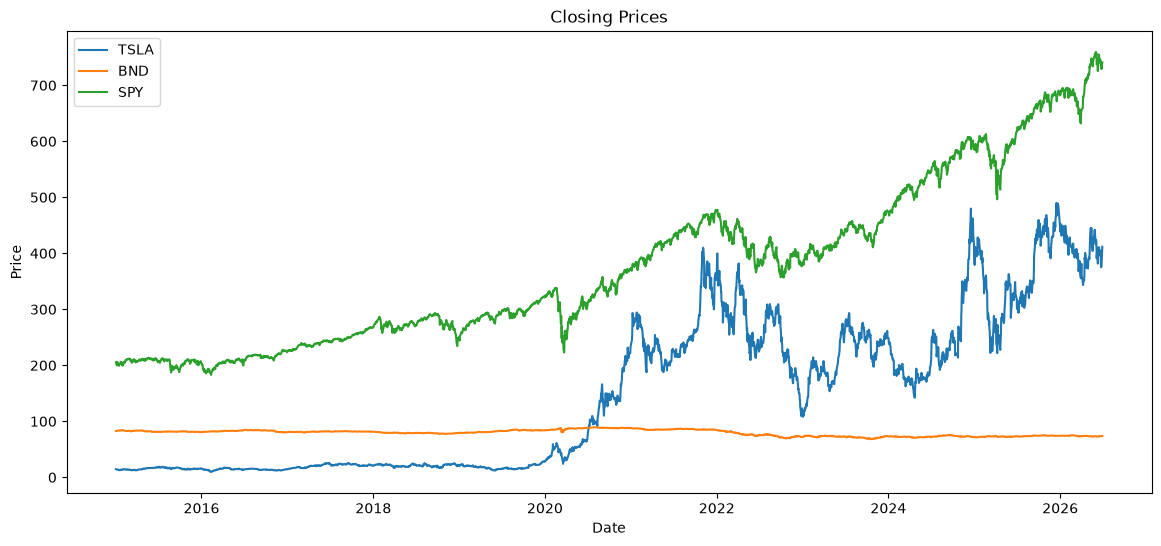

In [41]:
plt.figure(figsize=(14,6))

plt.plot(tsla["Date"], tsla["Close"], label="TSLA")

plt.plot(bnd["Date"], bnd["Close"], label="BND")

plt.plot(spy["Date"], spy["Close"], label="SPY")

plt.title("Closing Prices")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.show()

The closing price visualization indicates that Tesla shows much larger price growth and fluctuations than BND and SPY. BND remains relatively stable, while SPY exhibits a moderate upward trend.

## Daily Returns

In [42]:
for asset in [tsla, bnd, spy]:
    asset["Daily_Return"] = asset["Close"].pct_change()

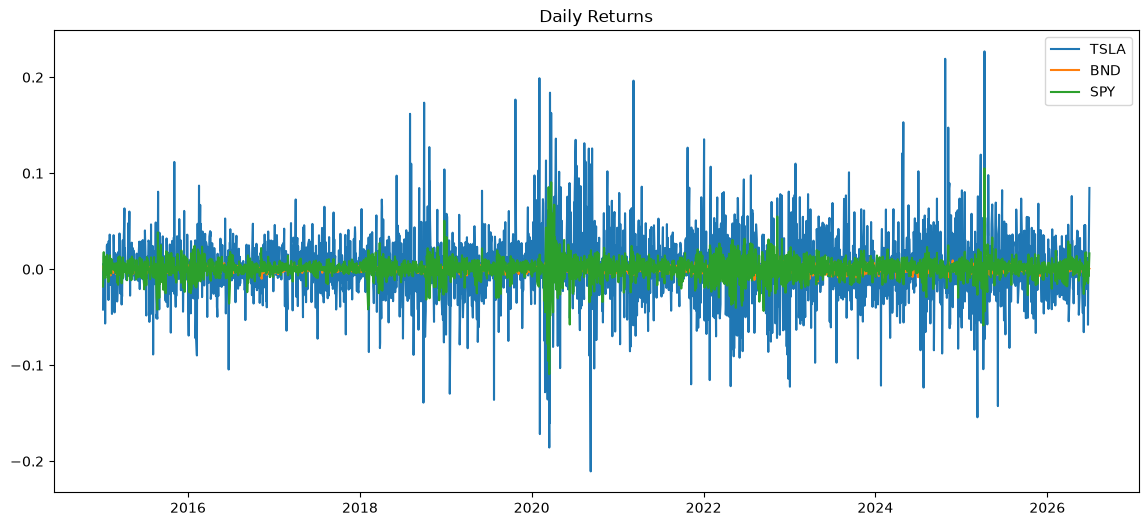

In [43]:
plt.figure(figsize=(14,6))

plt.plot(tsla["Date"], tsla["Daily_Return"], label="TSLA")

plt.plot(bnd["Date"], bnd["Daily_Return"], label="BND")

plt.plot(spy["Date"], spy["Daily_Return"], label="SPY")

plt.title("Daily Returns")

plt.legend()

plt.show()

Tesla experiences much larger daily fluctuations than BND and SPY, indicating higher volatility.

## Rolling Mean

In [44]:
for asset in [tsla, bnd, spy]:
    asset["Rolling_Mean"] = asset["Close"].rolling(30).mean()

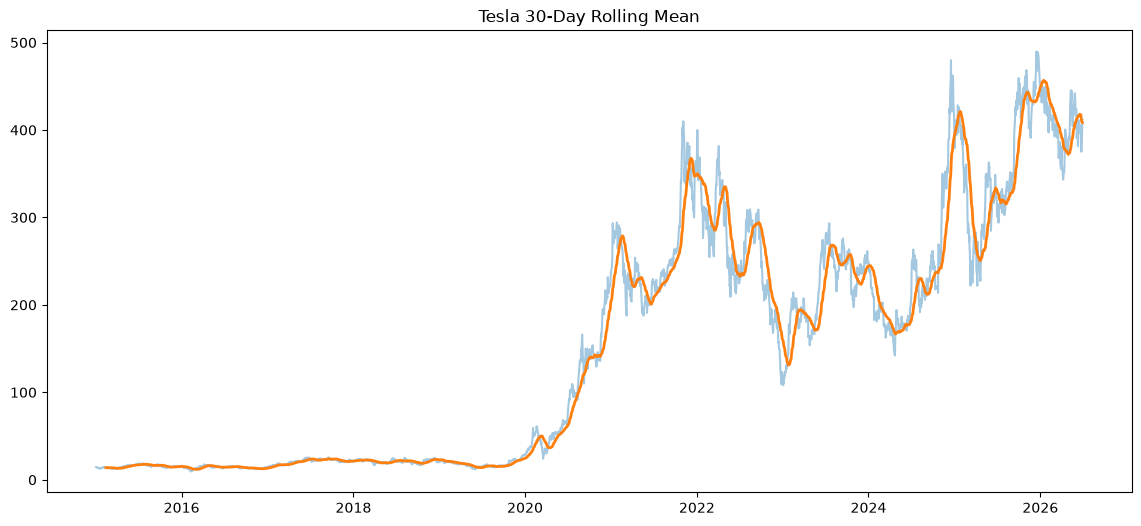

In [45]:
plt.figure(figsize=(14,6))

plt.plot(tsla["Date"], tsla["Close"], alpha=0.4)

plt.plot(tsla["Date"], tsla["Rolling_Mean"], linewidth=2)

plt.title("Tesla 30-Day Rolling Mean")

plt.show()

The 30-day rolling mean smooths short-term fluctuations in Tesla’s closing price and highlights the underlying trend. The comparison between the raw price and the rolling mean shows that Tesla experienced strong long-term growth, particularly after 2020, while daily prices exhibited significant volatility around this trend.

## Rolling Volatility

In [46]:
for asset in [tsla, bnd, spy]:
    asset["Rolling_STD"] = asset["Daily_Return"].rolling(30).std()

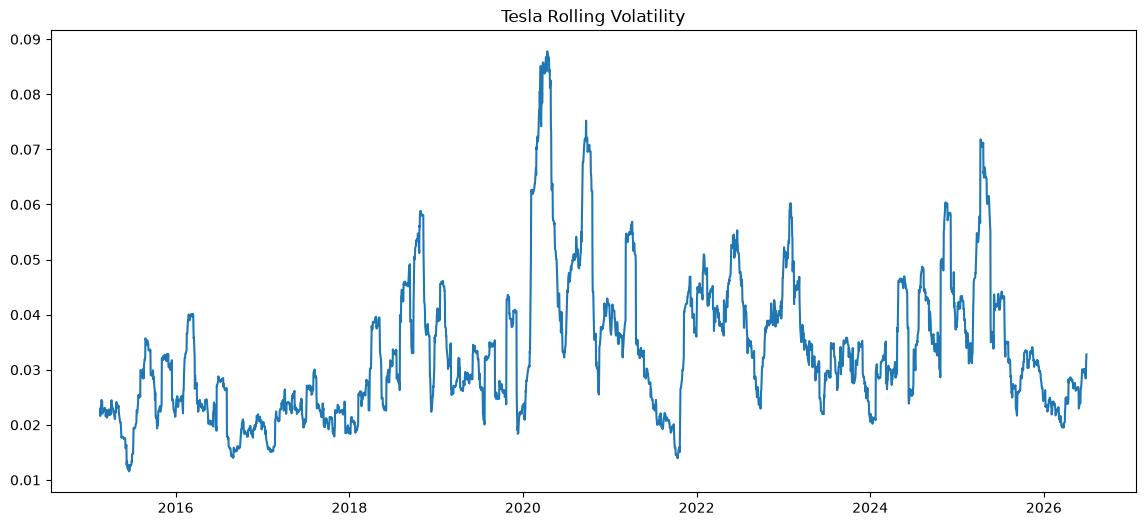

In [47]:
plt.figure(figsize=(14,6))

plt.plot(tsla["Date"], tsla["Rolling_STD"])

plt.title("Tesla Rolling Volatility")

plt.show()

Observation: The 30-day rolling standard deviation indicates that Tesla's volatility changed over time. Periods with higher peaks represent greater fluctuations in daily returns and therefore higher investment risk, while lower values indicate relatively stable market conditions.

If the graph stays mostly low with only occasional spikes:

Observation: Tesla experienced generally moderate volatility with several short periods of heightened market uncertainty, as shown by temporary increases in the 30-day rolling standard deviation.

## Distribution of Returns

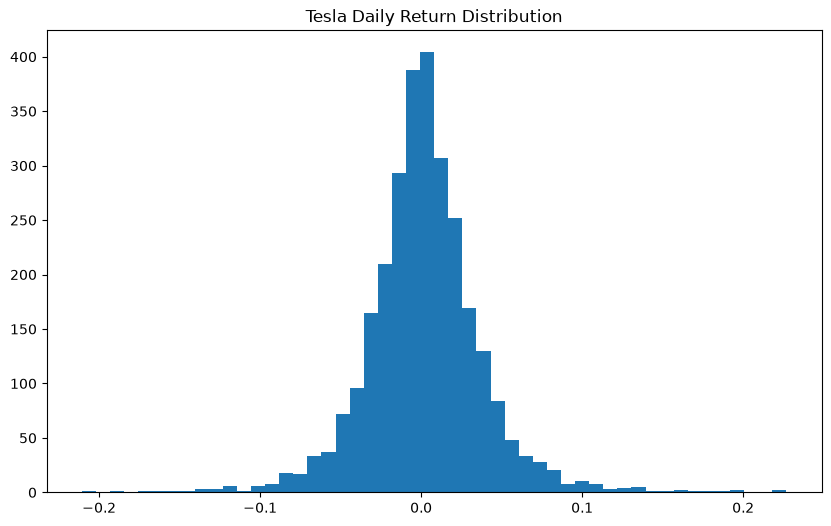

In [48]:
plt.figure(figsize=(10,6))

plt.hist(tsla["Daily_Return"].dropna(), bins=50)

plt.title("Tesla Daily Return Distribution")

plt.show()

Distribution of Daily Returns:
The histogram shows that Tesla's daily returns are concentrated around zero, indicating that most trading days experience relatively small price changes. The distribution has long tails on both sides, showing that although uncommon, Tesla occasionally experiences large positive and negative daily returns. These extreme observations reflect the stock's relatively high volatility and investment risk.

## Boxplot

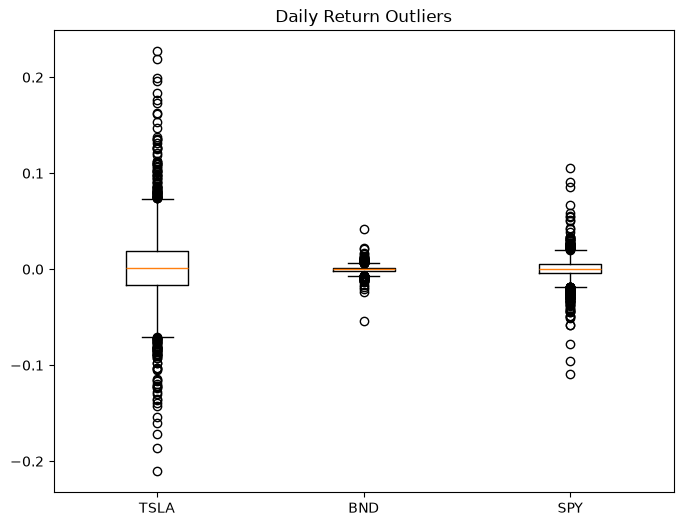

In [49]:
plt.figure(figsize=(8,6))

plt.boxplot([
    tsla["Daily_Return"].dropna(),
    bnd["Daily_Return"].dropna(),
    spy["Daily_Return"].dropna()
])

plt.xticks([1,2,3],["TSLA","BND","SPY"])

plt.title("Daily Return Outliers")

plt.show()

How to compare the three assets
TSLA

You'll likely see:

The tallest box.
Long whiskers.
Many outlier points.

This means:

Highest volatility.
More extreme daily gains and losses.
Highest investment risk.
BND

You'll likely see:

Very small box.
Short whiskers.
Few outliers.

This means:

Low volatility.
Stable returns.
Lowest investment risk.
SPY

You'll likely see:

Medium-sized box.
Moderate whiskers.
Some outliers.

This means:

Moderate volatility.
Moderate investment risk.

Outlier Detection:
The boxplot shows that Tesla has a wider spread of daily returns and a larger number of outliers compared with BND and SPY. This indicates that Tesla experiences more frequent extreme price movements, reflecting its higher volatility and investment risk. BND exhibits the smallest spread and very few outliers, demonstrating its role as a relatively stable, low-risk asset. SPY falls between the two, showing moderate variability and occasional extreme returns

## Identify Extreme Return Days

In [50]:
tsla.nlargest(5, "Daily_Return")[["Date","Daily_Return"]]

,Date,Daily_Return
8358,2025-04-09,0.226900
8245,2024-10-24,0.219190
7055,2020-02-03,0.198949
7331,2021-03-09,0.196412
7087,2020-03-19,0.183877


In [51]:
tsla.nsmallest(5, "Daily_Return")[["Date","Daily_Return"]]

,Date,Daily_Return
7206,2020-09-08,-0.210628
7084,2020-03-16,-0.185778
7057,2020-02-05,-0.171758
7086,2020-03-18,-0.160344
8336,2025-03-10,-0.154262


Analysis of Extreme Daily Returns:
The analysis identified the five largest and five smallest daily returns for Tesla over the study period. The highest one-day gain was approximately 22.69% on 2025-04-09, while the largest one-day loss was approximately 21.06% on 2020-09-08. These extreme observations confirm Tesla's high volatility and demonstrate that, although rare, substantial price movements can occur in both positive and negative directions.

## ADF Stationarity Test

In [52]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(tsla["Close"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.0695991394177469
p-value: 0.7270419411549218


ADF Test on Closing Prices:
The Augmented Dickey-Fuller test produced an ADF statistic of -1.07 with a p-value of 0.727. Since the p-value is greater than 0.05, we fail to reject the null hypothesis, indicating that Tesla's closing price series is non-stationary. This result is consistent with the long-term upward trend observed in the price chart. Therefore, the series should be transformed (e.g., by differencing) before applying forecasting models such as ARIMA.

In [53]:
result = adfuller(tsla["Daily_Return"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -53.97189280425144
p-value: 0.0


ADF Test on Daily Returns:
The Augmented Dickey-Fuller test on Tesla's daily returns produced an ADF statistic of -53.97 with a p-value of 0.0000. Since the p-value is less than 0.05, the null hypothesis of non-stationarity is rejected. This indicates that Tesla's daily return series is stationary, meaning its statistical properties remain relatively stable over time. This makes daily returns more suitable for time series modeling than raw closing prices.

## Value at Risk (VaR)

In [54]:
var_95 = tsla["Daily_Return"].quantile(0.05)

print("95% VaR:", var_95)

95% VaR: -0.05166375515284548


Value at Risk (VaR):
The 95% historical Value at Risk (VaR) for Tesla is -5.17%. This indicates that, based on historical daily returns, there is a 95% confidence that the daily loss will not exceed approximately 5.17%. Conversely, about 5% of trading days experienced losses greater than this threshold, highlighting Tesla's relatively high downside risk.

## Sharpe Ratio

In [55]:
sharpe = (
    tsla["Daily_Return"].mean()
    / tsla["Daily_Return"].std()
) * np.sqrt(252)

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 0.7944370048126019


Sharpe Ratio:
The annualized Sharpe Ratio for Tesla is 0.79, indicating that the stock generated a positive return relative to its risk, but with substantial volatility. While Tesla offers attractive return potential, its high price fluctuations reduce its risk-adjusted performance compared with more stable assets.

## Write Findings

The dataset contained historical prices for TSLA, BND, and SPY from 2015–2026.
The data was cleaned by flattening MultiIndex columns, converting the Date column to datetime, and verifying there were no missing or duplicate records.
Tesla exhibited the highest growth and the greatest volatility among the three assets.
BND remained relatively stable with the lowest volatility.
SPY showed moderate growth and moderate risk.
The ADF test indicated whether the closing prices were stationary and showed that daily returns are more suitable for ARIMA modeling.
VaR and Sharpe Ratio highlighted the trade-off between risk and return across the assets.